In [1]:
import spatialdata as sd
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import squidpy as sq
import anndata as ad

import seaborn as sns
import pickle
import warnings


/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/software/cellgen/team298/ls34/vqgraph/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata

In [2]:
PATH = '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
adata=sc.read_h5ad(PATH)
adata_5k=adata[adata.obs["tech"]=="xenium"].copy()
import gc
gc.collect()




def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST



/tmp/ipykernel_816137/4273487754.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["sample_id", "lvl5_annotation"]).size().reset_index(name="cell_count")


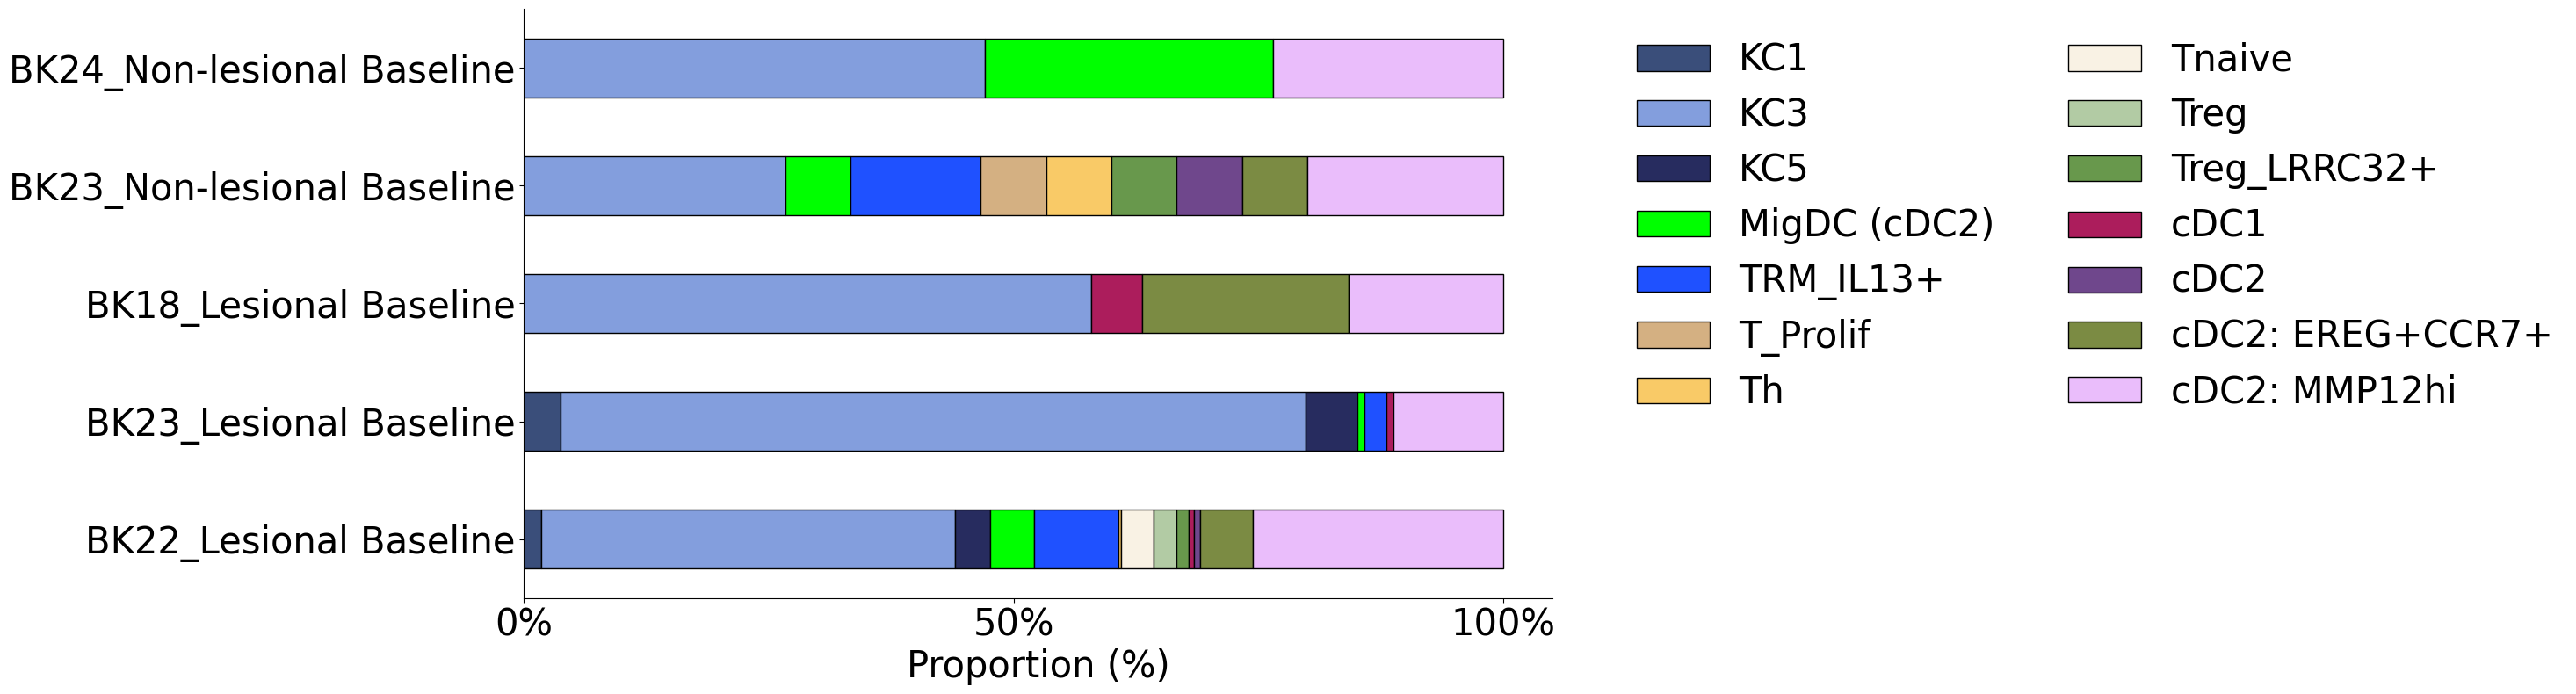

In [3]:
# Constants
NICHE11 = "Epidermis_APChi"  # Replace with your niche of interest
MINIMUM_PERCENT = 2
COLOR_PICKLE_PATH = '/nfs/team298/ls34/color_for_adult_skin2.pkl'

# Filter the data
adata_filtered = adata_5k[
    adata_5k.obs["niche19"].str.startswith(NICHE11)
]
sample_counts = adata_filtered.obs["sample_id"].value_counts()
valid_samples = sample_counts[sample_counts > 10].index
KEEP = ["Lesional", "Non-lesional"]
adata_filtered = adata_filtered[adata_filtered.obs["Site_status_binary"].isin(KEEP)]
adata_filtered = adata_filtered[adata_filtered.obs["sample_id"].isin(valid_samples)]

# Extract relevant columns
df = adata_filtered.obs[["sample_id", "lvl5_annotation", "disease_overall"]].copy()

# Count cell types per sample
grouped = df.groupby(["sample_id", "lvl5_annotation"]).size().reset_index(name="cell_count")

# Pivot to get counts matrix
pivot = grouped.pivot(index="sample_id", columns="lvl5_annotation", values="cell_count").fillna(0)

# Normalize to get percentages
proportions = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Filter out cell types with small contribution
proportions = proportions.loc[:, (proportions >= MINIMUM_PERCENT).any(axis=0)]
proportions = proportions.div(proportions.sum(axis=1), axis=0) * 100
# Get disease_overall per sample for sorting
sample_diseases = df.drop_duplicates("sample_id").set_index("sample_id")["disease_overall"]

# Sort samples by disease group
disease_order = sample_diseases.sort_values().index
proportions = proportions.loc[disease_order]

# Load colors
with open(COLOR_PICKLE_PATH, 'rb') as f:
    colors = pickle.load(f)

# Map colors to columns
plot_colors = [colors.get(cell_type, "grey") for cell_type in proportions.columns]

desired_order = [
    'BK22_Lesional Baseline',
    'BK23_Lesional Baseline',
    'BK18_Lesional Baseline',
    'BK23_Non-lesional Baseline',
    'BK24_Non-lesional Baseline'
]

# Reindex the proportions dataframe
proportions = proportions.reindex(desired_order)


# Plot horizontal barplot
fig, ax = plt.subplots(figsize=(30, 8))
proportions.plot(
    kind="barh",
    stacked=True,
    color=plot_colors,
    edgecolor="black",
    ax=ax
)

# Axis labels and formatting
ax.set_xlabel("Proportion (%)", fontsize=30)
ax.set_ylabel("", fontsize=30)
ax.set_title("", fontsize=1)

# Y-axis: sample IDs
ax.set_yticks(range(len(proportions)))
ax.set_yticklabels(proportions.index, fontsize=30)

# X-axis: percentage ticks
ax.set_xticks([0, 50, 100])
ax.set_xticklabels(["0%", "50%", "100%"], fontsize=30)

# Legend
ax.legend(
    title="",
    labels=proportions.columns,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=30,
    #title_fontsize=30,
    frameon=False,
    ncols=2
)

# Clean up
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figures/e7b_epidermisapchi.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [4]:
s

NameError: name 's' is not defined

In [ ]:
# NICHE = "Epidermis_APChi"#"Epidermis_Inflamm_immune"
# print(NICHE)

# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# adata_5k_i= adata_5k#[adata_5k_i.obs["Timepoint"] == "Lesional"]
# sample_counts = adata_5k_i.obs["info_id6"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 10].index
# SAMPLES=[]

# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["info_id6"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]
#     TIMEPOINT =  adata_i.obs["Timepoint"].unique()[0]
#     DONOR =  adata_i.obs["Sanger patient ID"].unique()[0]


#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     niche_names_found = adata_i.obs["niche19"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche19"]==NICHE]
#         CELL_COUNT = adata_ii.shape[0]
#         print("Cell count for slide: ", CELL_COUNT)
#         print()
#         if CELL_COUNT > 10:
#     #         if i ==0:
#             SAMPLES.append(DONOR_ID)
#             sq.pl.spatial_scatter(
#                 adata_i,
#                 library_id="spatial",
#                 shape=None,
#                 color="niche19",
#                 size=60,
#                 vmax=1,
#                 title=DONOR_ID,# + "_" + STATUS + "_" + TIMEPOINT + "_" + DONOR + "_n=" +  str(CELL_COUNT),
#                 edgecolor='black',
#                 linewidth=0.1,
#                 legend_loc=None
#                 #ax=ax,
#                 #legend_loc="on data"  # Disable the legend for each subplot
#             )       
#             i=i+1

            
            
# SAMPLES

In [ ]:
sc.pp.normalize_total(adata_5k, target_sum=1e4)
sc.pp.log1p(adata_5k)

In [ ]:
mac_markers={ 
   # 'other': ['CD14', 'IL23A'],
 'cDC1': ['CLEC9A'],
 'cDC2': ['CLEC10A', 'CD1B', 'CD1C', "CD163", 'CD1E', # 'CD5', 
          #'SPIB', 'TNFSF4', 'TSPAN2'
         ],

             'cDC2B_subtype_MMP12': ['MMP12', "CST6", "GGT5", "CARD9",  "ALOX15", "CXCL9",#'CROCC',
                   ],
              'cDC2B_subtype_EREG+': ["ITGAV","LAMB3", 
 "EREG",'IL1B', #'CROCC',

                                       #"SATB1",
                                     # "EHD1", "LUCAT1", "ITGAV", "OLR1", "TNFRSF4", "DOT1L", "DOCK4",
          #    "ADA", "MMP19", "ELK1", "LAMB3", "MIR3142HG", "GPR35",   "ISG20", "CXCL3", "MMP9",  
                   ],
                    "Cycling": ["TOP2A", "MKI67"],
             # 'MoDC': ["PLK2", "KLF2", "THBS1"
             #     #'THBS1',  'C1QTNF1', "INHBA", "TNFRSF4"
             # ],

 'LC': ['CD207','FCGBP', "EPCAM", 'CD1A', "SLC18A2", "TMEM45A", "IL22RA2","NMU" #"CLEC4A"
       ],
              'Migrating': ['CCR7', 'LAMP3',  ], 

 'MigDC': ['LY75', "CD200",  "BATF3",'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
           "CD274", "PDCD1LG2",  "TNFSF4", "PVR", "RAMP1" , "EBI3","ICOSLG",
          "TREML1", "CD80", ],  #'ST8SIA1', 'CCL19', "CCL17", "CCL22",
         
     #"TFPI", "SERINC2", #"IL10",
          #'LILRA1', 'LILRA2'
             "MigDC(cDC2)": ["ANXA3"],
             "T_survival/attracting": ["IL12B", "IL15",  "CCL22", "CCL17", ],
 
 
      
            }

# adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype("category").cat.remove_unused_categories()
# adata_5k_i.obs[CATEGORY] = adata_5k_i.obs[CATEGORY].astype("category").cat.remove_unused_categories()

# sc.pl.dotplot(adata_i, 
#               remove_markers(mac_markers),
#               groupby=CATEGORY, 
#               dendrogram=False, 
#                 standard_scale="var",
#                                          colorbar_title="Mean expression\n(minmax norm.)",

#                      save="myeloid_scrna.pdf")
adata_5k_i=adata_5k[adata_5k.obs["lvl1_new"]=="Myeloid"]

import pandas as pd

# Get counts per category
counts = adata_5k_i.obs["lvl5_annotation"].value_counts()

# Identify categories with >= 5 cells
keep_categories = counts[counts >= 5].index

# Subset AnnData to only keep those cells
adata_5k_i = adata_5k_i[adata_5k_i.obs["lvl5_annotation"].isin(keep_categories)].copy()

# Optionally, clean up the categories to drop unused ones
adata_5k_i.obs["lvl5_annotation"] = adata_5k_i.obs["lvl5_annotation"].astype("category")
#adata_5k_i.obs["lvl5_annotation"].cat.remove_unused_categories(inplace=True)
ORDER=[ 'cDC1','cDC2',
       'cDC2: MMP12hi',
       'cDC2: EREG+CCR7+',
       'MigDC (cDC2)', ]

sc.pl.dotplot(adata_5k_i, 
              remove_markers(["CD274"]),
              groupby="lvl5_annotation",
              dendrogram=False, 
             colorbar_title="Mean expression\n(minmax norm.)",
              #categories_order=ORDER,

                #standard_scale="var", 
              dot_max=0.6,
          #   save="myeloid_xenium.pdf"
             )

In [ ]:
# mac_markers={ 
#    # 'other': ['CD14', 'IL23A'],
#  'cDC1': ['CLEC9A'],
#  'cDC2': ['CLEC10A', 'CD1B', 'CD1C', 
#           #'SPIB', 'TNFSF4', 'TSPAN2'
#          ],

#              'cDC2B_subtype_MMP12': ['MMP12', "CST6", "GGT5", "CARD9",  "ALOX15", 
#                    ],
#               'cDC2B_subtype_EREG+': ["ITGAV","LAMB3", 
#  "EREG",'IL1B', #'CROCC',

#                                        #"SATB1",
#                                      # "EHD1", "LUCAT1", "ITGAV", "OLR1", "TNFRSF4", "DOT1L", "DOCK4",
#           #    "ADA", "MMP19", "ELK1", "LAMB3", "MIR3142HG", "GPR35",   "ISG20", "CXCL3", "MMP9",  
#                    ],
#                     "Cycling": ["TOP2A", "MKI67"],
#              # 'MoDC': ["PLK2", "KLF2", "THBS1"
#              #     #'THBS1',  'C1QTNF1', "INHBA", "TNFRSF4"
#              # ],

#  'LC': ['CD207','FCGBP', "EPCAM", 'CD1A', "SLC18A2", "TMEM45A", "IL22RA2","NMU" #"CLEC4A"
#        ],
#               'Migrating': ['CCR7', 'LAMP3',  ], 

#  'MigDC': ['LY75', "CD200",  "BATF3",'SLCO5A1', 'WNT5B', 'ADAM12', "ACHE",
#            "CD274", "PDCD1LG2",  "TNFSF4", "PVR", "RAMP1" , "EBI3","ICOSLG",
#           "TREML1", "CD80", ],  #'ST8SIA1', 'CCL19', "CCL17", "CCL22",
         
#      #"TFPI", "SERINC2", #"IL10",
#           #'LILRA1', 'LILRA2'
#              "MigDC(cDC2)": ["ANXA3"],
#              "T_survival/attracting": ["IL12B", "IL15",  "CCL22", "CCL17", ],
 
 
      
#             }

# # adata_i.obs[CATEGORY] = adata_i.obs[CATEGORY].astype("category").cat.remove_unused_categories()
# # adata_5k_i.obs[CATEGORY] = adata_5k_i.obs[CATEGORY].astype("category").cat.remove_unused_categories()

# # sc.pl.dotplot(adata_i, 
# #               remove_markers(mac_markers),
# #               groupby=CATEGORY, 
# #               dendrogram=False, 
# #                 standard_scale="var",
# #                                          colorbar_title="Mean expression\n(minmax norm.)",

# #                      save="myeloid_scrna.pdf")
# adata_5k_i=adata_5k[adata_5k.obs["niche19"]=="Epidermis_APChi"]
# adata_5k_i=adata_5k_i[adata_5k_i.obs["lvl1_new"]=="Myeloid"]

# import pandas as pd

# # Get counts per category
# counts = adata_5k_i.obs["lvl5_annotation"].value_counts()

# # Identify categories with >= 5 cells
# keep_categories = counts[counts >= 5].index

# # Subset AnnData to only keep those cells
# adata_5k_i = adata_5k_i[adata_5k_i.obs["lvl5_annotation"].isin(keep_categories)].copy()

# # Optionally, clean up the categories to drop unused ones
# adata_5k_i.obs["lvl5_annotation"] = adata_5k_i.obs["lvl5_annotation"].astype("category")
# #adata_5k_i.obs["lvl5_annotation"].cat.remove_unused_categories(inplace=True)
# ORDER=[ 'cDC1','cDC2',
#        'cDC2: MMP12hi',
#        'cDC2: EREG+CCR7+',
#        'MigDC (cDC2)', ]

# sc.pl.dotplot(adata_5k_i, 
#               remove_markers(mac_markers),
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#              colorbar_title="Mean expression\n(minmax norm.)",
#               categories_order=ORDER,

#                 standard_scale="var", 
#               dot_max=0.6,
#           #   save="myeloid_xenium.pdf"
#              )

In [ ]:
# sc.pl.dotplot(adata_5k[adata_5k.obs["lvl1_new"]=="Myeloid"], 
#               remove_markers(mac_markers),
#               groupby="lvl5_annotation",
#               dendrogram=False, 
#              colorbar_title="Mean expression\n(minmax norm.)",
#              # categories_order=ORDER,

#                 #standard_scale="var", 
#               dot_max=0.6,
#           #   save="myeloid_xenium.pdf"
#              )

In [ ]:


# group_col = "lvl5_annotation"
# counts = adata_5k_i.obs[group_col].value_counts()

# # Build a new column for labeled categories, e.g. "Macrophage_n=312"
# adata_5k_i.obs[group_col + "_labeled"] = adata_5k_i.obs[group_col].map(
#     lambda x: f"{x}_n={counts.get(x, 0)}"
# )

# # Ensure the order matches your ORDER list
# ORDER_LABELED = [f"{x}_n={counts.get(x, 0)}" for x in ORDER if x in counts.index]

# # Plot
# sc.pl.dotplot(
#     adata_5k_i,
#     remove_markers(mac_markers),
#     groupby=group_col + "_labeled",
#     dendrogram=False,
#     colorbar_title="Mean expression\n(minmax norm.)",
#     categories_order=ORDER_LABELED,
#     dot_max=0.6,
#     standard_scale="var",
#     save="EPIDERMISapchi_myeloid_dotplot.pdf"
# )

In [ ]:
counts = adata_5k_i.obs["lvl5_annotation"].value_counts()

# Identify categories with >= 5 cells
keep_categories = counts[counts >= 5].index

# Subset AnnData to only keep those cells
adata_5k_i = adata_5k_i[adata_5k_i.obs["lvl5_annotation"].isin(keep_categories)].copy()

# Optionally, clean up the categories to drop unused ones
adata_5k_i.obs["lvl5_annotation"] = adata_5k_i.obs["lvl5_annotation"].astype("category")
#adata_5k_i.obs["lvl5_annotation"].cat.remove_unused_categories(inplace=True)

print("Remaining categories:")
print(adata_5k_i.obs["lvl5_annotation"].cat.categories)

In [ ]:

# NICHE = "Epidermis_APChi"#"Epidermis_Inflamm_immune"
# print(NICHE)

# sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False, figsize=(18,18))

# adata_5k_i= adata_5k#[adata_5k_i.obs["Timepoint"] == "Lesional"]
# sample_counts = adata_5k_i.obs["info_id2"].value_counts()
# samples_to_keep = sample_counts[sample_counts > 100].index
# SAMPLES=[]

# ORDER = []
# for i,DONOR_ID in enumerate(samples_to_keep):
#     print(i+1, "/", len(samples_to_keep))
#     adata_i =  adata_5k_i[adata_5k_i.obs["info_id2"]==DONOR_ID]
#     STATUS =  adata_i.obs["Site_status"].unique()[0]
#     TIMEPOINT =  adata_i.obs["Timepoint"].unique()[0]
#     DONOR =  adata_i.obs["Sanger patient ID"].unique()[0]


#     #RUN_ID = list(adata_i.obs.RUN_ID.unique())[0]
#     INFO_ID = list(adata_i.obs.info_id.unique())[0]
#     niche_names_found = adata_i.obs["niche12"].unique()
   
#     if NICHE in niche_names_found:
#         adata_ii =  adata_i[adata_i.obs["niche12"]==NICHE]
#         CELL_COUNT = adata_ii.shape[0]
#         print("Cell count for slide: ", CELL_COUNT)
#         print()
#         if CELL_COUNT > 100:
#     #         if i ==0:
#             SAMPLES.append(DONOR_ID)
#             sq.pl.spatial_scatter(
#                 adata_ii,
#                 library_id="spatial",
#                 shape=None,
#                 color="lvl4_annotation",
#                 size=600,
#                 vmax=1,
#                 title=DONOR_ID + "_" + STATUS + "_" + TIMEPOINT + "_" + DONOR + "_n=" +  str(CELL_COUNT),
#                 edgecolor='black',
#                 linewidth=0.1,
#                 #legend_loc=None
#                 #ax=ax,
#                 #legend_loc="on data"  # Disable the legend for each subplot
#             )       
#             i=i+1
#             adata_ii = adata_i[adata_i.obs["niche12"]=="Sebaceous_immune"]

            
            
# SAMPLES